# Lab Data Preparation : Diabetes 130-US Hospitals (1999-2008)

## 1. Business Understanding

**Contexte** : Les réadmissions hospitalières précoces chez les patients diabétiques
sont coûteuses et révèlent souvent une prise en charge insuffisante. Le dataset
contient 10 ans de données de 130 hôpitaux américains (~100 000 séjours).

**Problématique de classification** : prédire si un patient diabétique sera
réadmis dans les 30 jours suivant sa sortie (`readmitted = <30`).

**Problématique de segmentation** : identifier des profils de patients
(durée de séjour, nombre de médicaments, historique d'hospitalisations, âge)
afin de repérer des groupes à risque.

**Objectifs** : explorer et nettoyer les données, puis construire des modèles
de clustering et de classification, évalués par des métriques adaptées
au déséquilibre de classes (recall, F1, AUC-ROC).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv("../data/raw/diabetic_data.csv", na_values="?")
print(df.shape)
df.head()

(101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [8]:
#df.info()
#df.describe().T
# Pourcentage de valeurs manquantes par colonne
#missing = (df.isna().mean() * 100).sort_values(ascending=False)
#missing[missing > 0]
# Distribution de la cible
df["readmitted"].value_counts(normalize=True)

readmitted
NO     0.539119
>30    0.349282
<30    0.111599
Name: proportion, dtype: float64

## 2. Data Understanding

- Dataset : 101 766 séjours, 50 variables (13 numériques, 37 catégorielles).
- Cible `readmitted` : NO (53,9 %), >30 (34,9 %), <30 (11,2 %) : classes déséquilibrées.
- `weight` est manquant à 96,9 % : inexploitable.
- `max_glu_serum` et `A1Cresult` : la valeur "None" signifie test non réalisé,
  et non une donnée manquante : à conserver comme catégorie.
- Les variables *_id sont des codes catégoriels, pas des quantités.
- Les variables number_* sont fortement asymétriques (outliers probables).

In [12]:
# 1. Doublons et patients répétés
print("Lignes dupliquées :", df.duplicated().sum())
print("Encounters uniques :", df["encounter_id"].nunique())
print("Patients uniques   :", df["patient_nbr"].nunique())
# 2. Valeurs des variables catégorielles clés
for col in ["gender", "race", "age", "admission_type_id",
            "discharge_disposition_id", "admission_source_id"]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(12))
# 3. Colonnes quasi constantes
cat_cols = df.select_dtypes(exclude="number").columns
for col in cat_cols:
    top = df[col].value_counts(normalize=True, dropna=False).iloc[0]
    if top > 0.95:
        print(f"{col}: {top:.2%} de la valeur dominante")
    # 4. Mapping officiel des codes
pd.read_csv("../data/raw/IDS_mapping.csv").head(40)

Lignes dupliquées : 0
Encounters uniques : 101766
Patients uniques   : 71518

--- gender ---
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

--- race ---
race
Caucasian          76099
AfricanAmerican    19210
NaN                 2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

--- age ---
age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64

--- admission_type_id ---
admission_type_id
1    53990
3    18869
2    18480
6     5291
5     4785
8      320
7       21
4       10
Name: count, dtype: int64

--- discharge_disposition_id ---
discharge_disposition_id
1     60234
3     13954
6     12902
18     3691
2      2128
22     1993
11     1642
5      1184
25      989
4       815
7       623
23      412
Name: count, dtype:

,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available
5,6,NaN
6,7,Trauma Center
7,8,Not Mapped
8,NaN,NaN
9,discharge_disposition_id,description


### Problèmes de qualité identifiés (suite)
- 3 lignes avec gender = Unknown/Invalid : à supprimer.
- race manquante (2,2 %) : catégorie "Unknown".
- Colonnes quasi constantes (médicaments combinés) : à supprimer.
- Patients décédés ou en hospice (discharge_disposition_id 11, 13, 14, 19, 20, 21) :
  non réadmissibles, à exclure.
- admission_type_id 5, 6, 8 : valeurs inconnues à regrouper.

In [16]:
# 1. Doublons et patients répétés
print("Lignes dupliquées :", df.duplicated().sum())
print("Encounters uniques :", df["encounter_id"].nunique())
print("Patients uniques   :", df["patient_nbr"].nunique())
print("Patients avec >1 séjour :", (df["patient_nbr"].value_counts() > 1).sum())
# 2. Toutes les colonnes quasi constantes (seuil 99 %)
for col in df.columns:
    top = df[col].value_counts(normalize=True, dropna=False).iloc[0]
    if top > 0.99:
        print(f"{col}: {top:.2%}")
# 3. Combien de patients décédés / en hospice ?
exclus = [11, 13, 14, 19, 20, 21]
print("Séjours à exclure :", df["discharge_disposition_id"].isin(exclus).sum())
print(df[df["discharge_disposition_id"].isin(exclus)]["readmitted"].value_counts())
# 4. Âge : affichage ordonné
print(df["age"].value_counts().sort_index())

Lignes dupliquées : 0
Encounters uniques : 101766
Patients uniques   : 71518
Patients avec >1 séjour : 16773
nateglinide: 99.31%
chlorpropamide: 99.92%
acetohexamide: 100.00%
tolbutamide: 99.98%
acarbose: 99.70%
miglitol: 99.96%
troglitazone: 100.00%
tolazamide: 99.96%
examide: 100.00%
citoglipton: 100.00%
glyburide-metformin: 99.31%
glipizide-metformin: 99.99%
glimepiride-pioglitazone: 100.00%
metformin-rosiglitazone: 100.00%
metformin-pioglitazone: 100.00%
Séjours à exclure : 2423
readmitted
NO     2337
<30      43
>30      43
Name: count, dtype: int64
age
[0-10)        161
[10-20)       691
[20-30)      1657
[30-40)      3775
[40-50)      9685
[50-60)     17256
[60-70)     22483
[70-80)     26068
[80-90)     17197
[90-100)     2793
Name: count, dtype: int64


### Résultats de la Data Understanding
- Aucun doublon exact ; 71 518 patients uniques pour 101 766 séjours
  (16 773 patients avec plusieurs séjours) : risque de fuite de données
  à gérer lors du split train/test (GroupShuffleSplit sur patient_nbr).
- 15 colonnes de médicaments quasi constantes (>99 %) : à supprimer.
- 2 423 séjours de patients décédés ou en hospice (dont 96,5 % "NO") :
  à exclure, car non réadmissibles.
- age : tranches ordonnées de 10 ans, concentrées entre 50 et 90 ans :
  à encoder de façon ordinale.

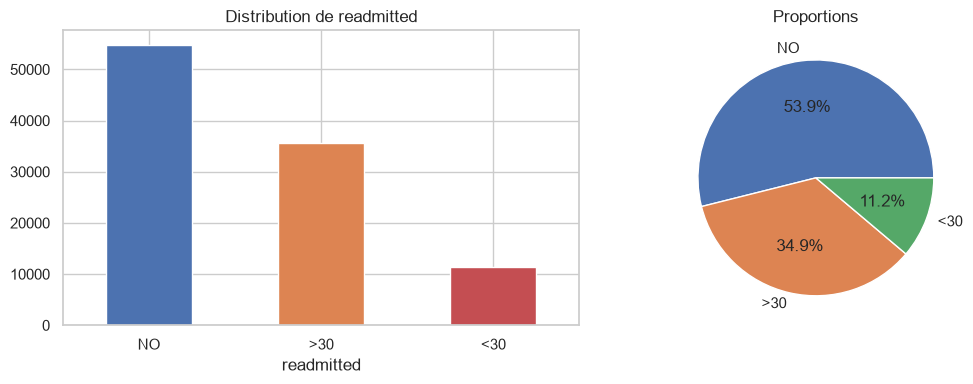

In [17]:
# 1. Distribution de la cible
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
df["readmitted"].value_counts().plot(kind="bar", ax=ax[0], color=["#4C72B0", "#DD8452", "#C44E52"])
ax[0].set_title("Distribution de readmitted")
ax[0].tick_params(axis="x", rotation=0)

df["readmitted"].value_counts().plot(kind="pie", autopct="%1.1f%%", ax=ax[1])
ax[1].set_ylabel("")
ax[1].set_title("Proportions")
plt.tight_layout()
plt.show()

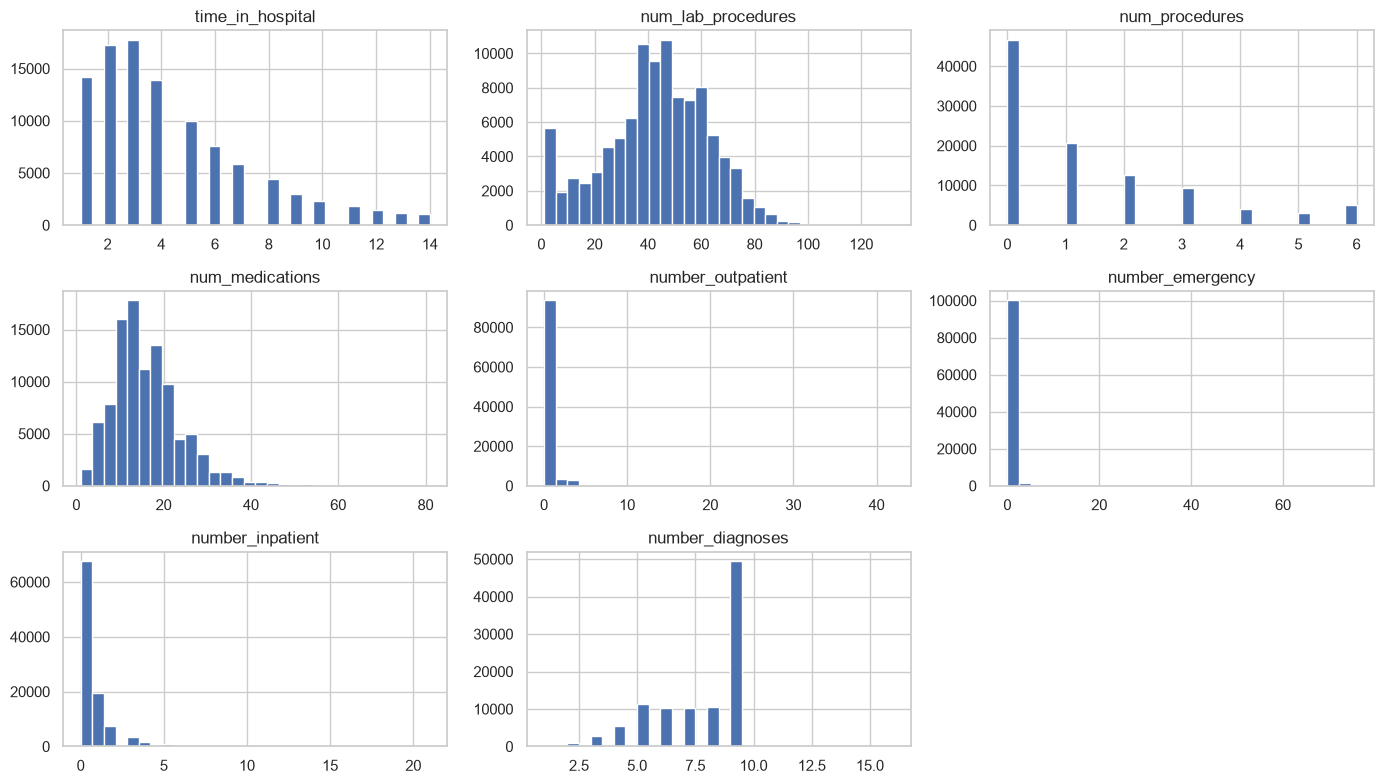

In [18]:
# 2. Distributions des variables numériques
num_cols = ["time_in_hospital", "num_lab_procedures", "num_procedures",
            "num_medications", "number_outpatient", "number_emergency",
            "number_inpatient", "number_diagnoses"]

df[num_cols].hist(bins=30, figsize=(14, 8))
plt.tight_layout()
plt.show()

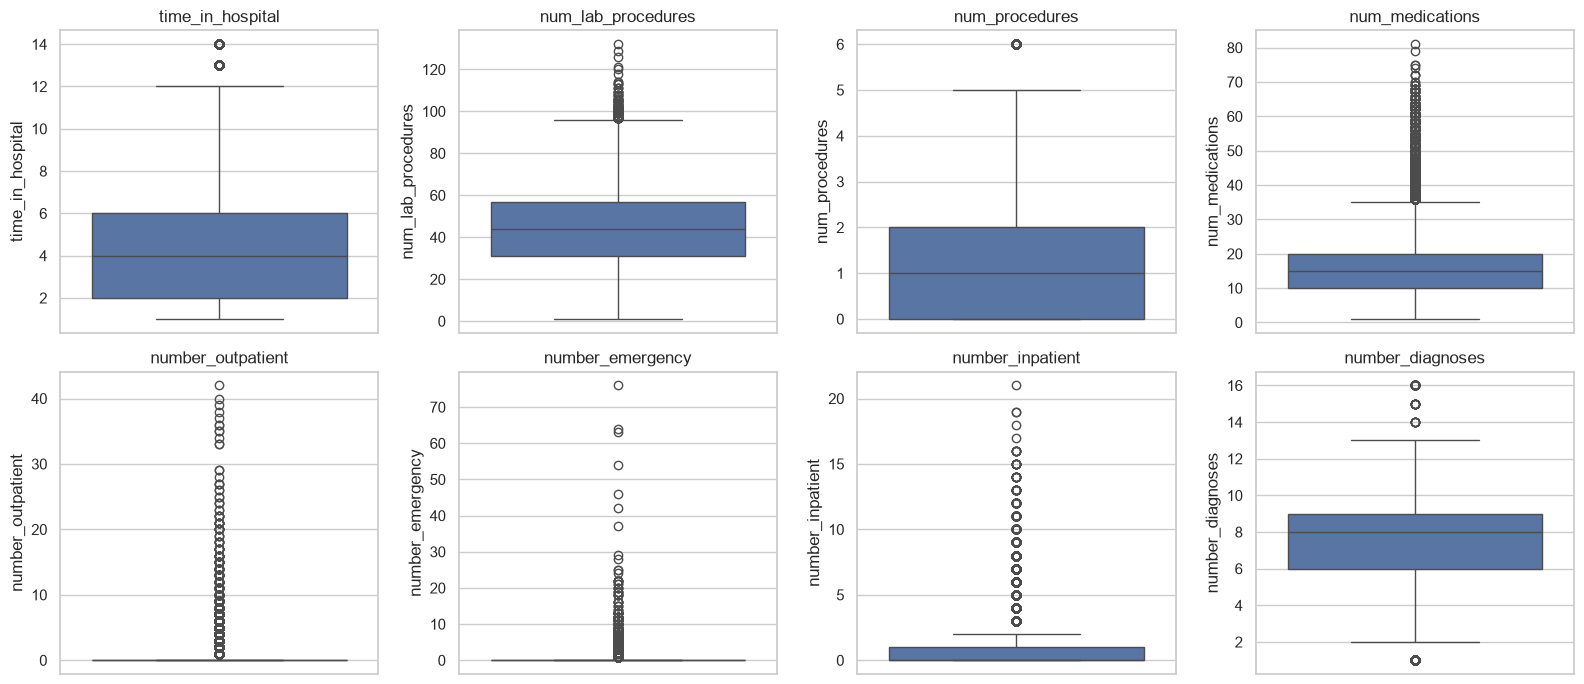

In [19]:
# 3. Boxplots pour repérer les outliers
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), num_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

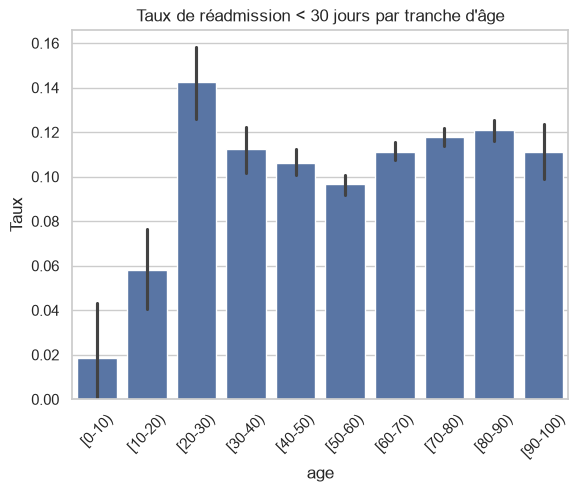

In [20]:
# 4. Réadmission < 30 jours selon l'âge
df["readmit_30"] = (df["readmitted"] == "<30").astype(int)
age_order = sorted(df["age"].unique())
sns.barplot(data=df, x="age", y="readmit_30", order=age_order)
plt.xticks(rotation=45)
plt.title("Taux de réadmission < 30 jours par tranche d'âge")
plt.ylabel("Taux")
plt.show()

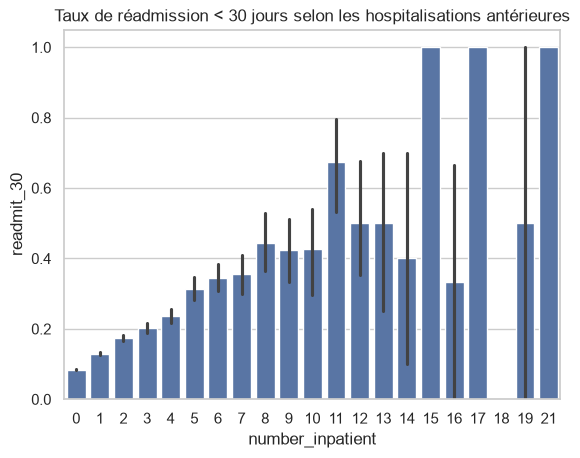

In [21]:
# 5. Réadmission selon number_inpatient (probable variable clé)
sns.barplot(data=df, x="number_inpatient", y="readmit_30")
plt.title("Taux de réadmission < 30 jours selon les hospitalisations antérieures")
plt.show()

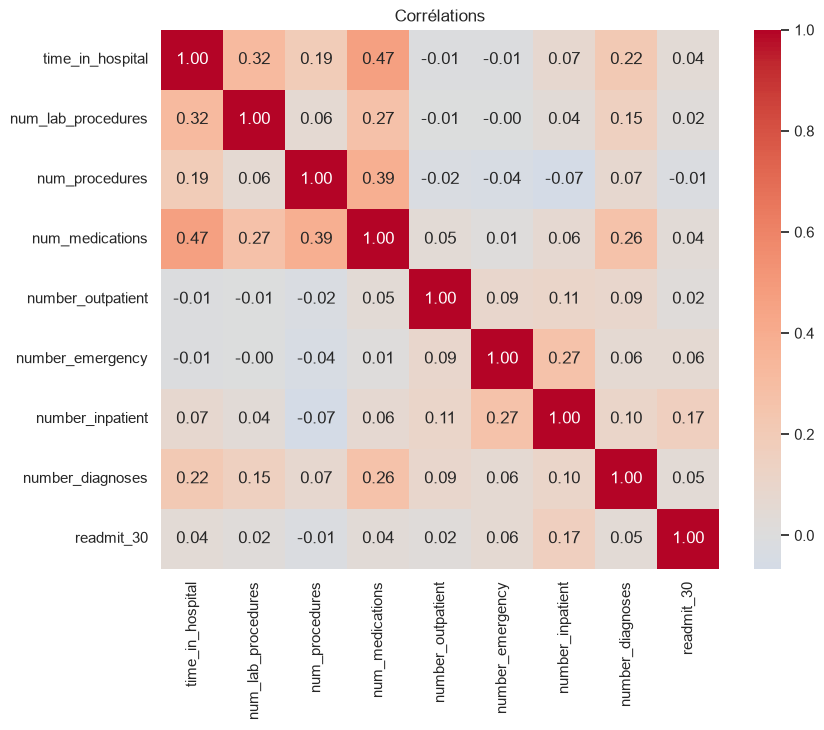

In [22]:
# 6. Matrice de corrélation
plt.figure(figsize=(9, 7))
sns.heatmap(df[num_cols + ["readmit_30"]].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Corrélations")
plt.show()

## 3. Data Exploration : observations

- La cible est déséquilibrée (<30 : 11,2 %) : accuracy inadaptée, on utilisera recall, F1 et AUC.
- Les variables number_outpatient, number_emergency et number_inpatient sont
  très asymétriques (>90 % de zéros) : transformation log ou regroupement.
- Les outliers (num_medications, number_*) sont médicalement plausibles :
  winsorisation plutôt que suppression.
- number_diagnoses plafonne à 9 (limite de saisie probable).
- number_inpatient est le prédicteur le plus net : le taux de réadmission passe de ~8 %
  (0 hospitalisation) à >30 % (5 et plus). Corrélation avec la cible : 0,17.
- L'âge a un effet modéré et non linéaire (pic à 20-30 ans, petits effectifs).
- Corrélations faibles entre variables (max 0,47) : pas de multicolinéarité grave.
- Corrélations faibles avec la cible : problème difficile, performances modestes attendues.

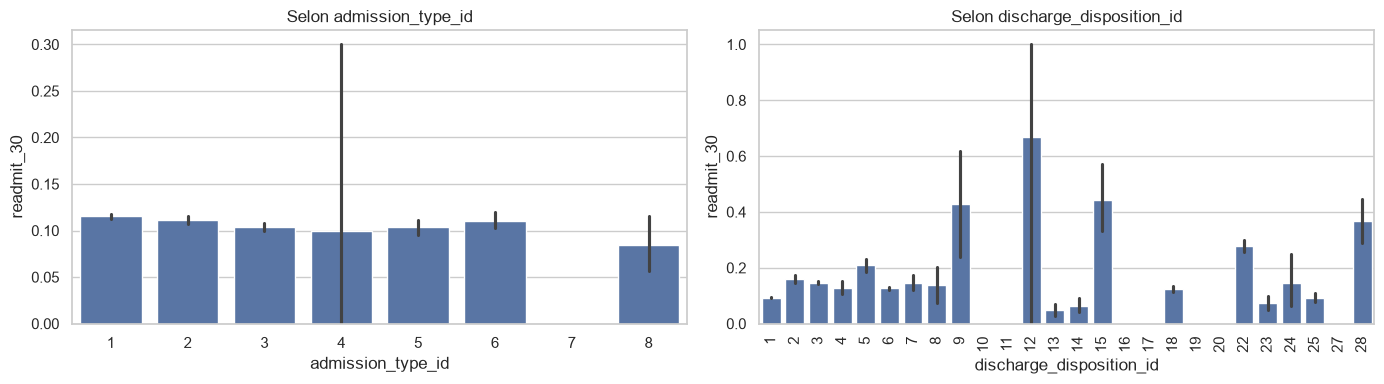

In [23]:
# 1. Réadmission selon le type d'admission et la sortie
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=df, x="admission_type_id", y="readmit_30", ax=ax[0])
ax[0].set_title("Selon admission_type_id")
sns.barplot(data=df, x="discharge_disposition_id", y="readmit_30", ax=ax[1])
ax[1].set_title("Selon discharge_disposition_id")
ax[1].tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

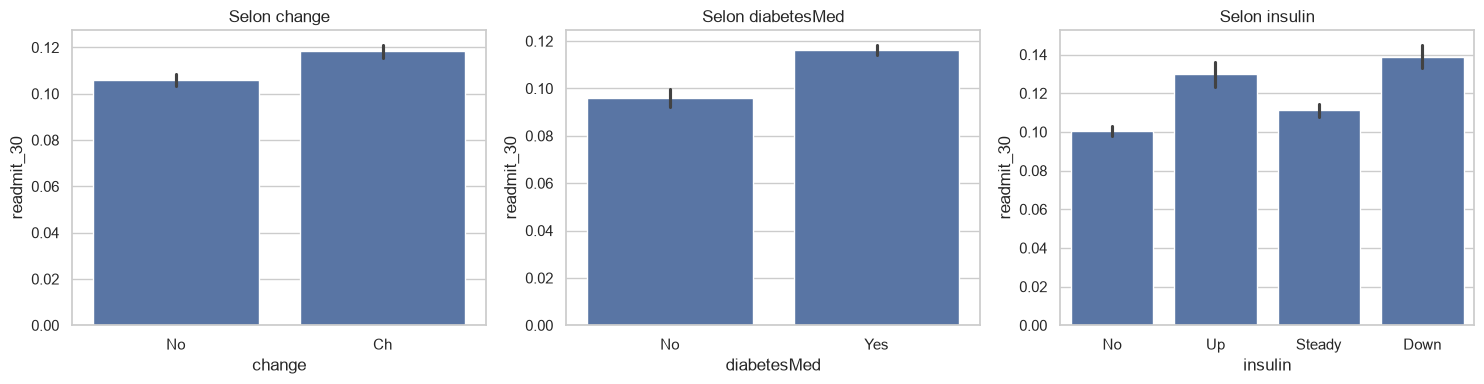

In [24]:
# 2. Réadmission selon le traitement
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, col in zip(ax, ["change", "diabetesMed", "insulin"]):
    sns.barplot(data=df, x=col, y="readmit_30", ax=a)
    a.set_title(f"Selon {col}")
plt.tight_layout()
plt.show()

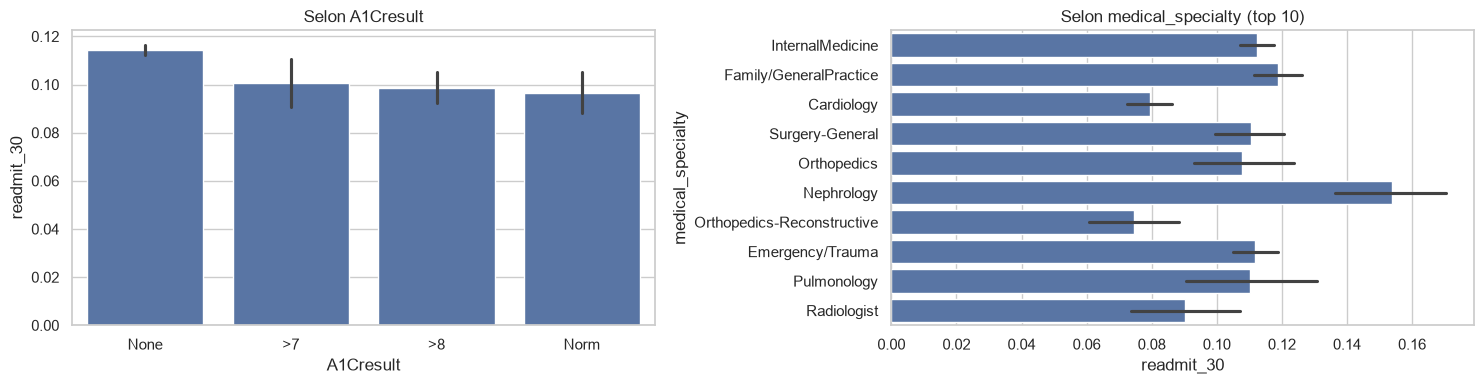

In [28]:
# 3. Réadmission selon le test HbA1c et la spécialité médicale
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
sns.barplot(data=df.fillna({"A1Cresult": "None"}), x="A1Cresult", y="readmit_30", ax=ax[0])
ax[0].set_title("Selon A1Cresult")
top_spec = df["medical_specialty"].value_counts().head(10).index
sns.barplot(data=df[df["medical_specialty"].isin(top_spec)], y="medical_specialty", x="readmit_30", ax=ax[1])
ax[1].set_title("Selon medical_specialty (top 10)")
plt.tight_layout()
plt.show()

In [29]:
# 4. Top 10 des codes diagnostics (diag_1)
df["diag_1"].value_counts().head(10)

diag_1
428    6862
414    6581
786    4016
410    3614
486    3508
427    2766
491    2275
715    2151
682    2042
434    2028
Name: count, dtype: int64

### Exploration des variables catégorielles
- admission_type_id : peu discriminant ; regrouper les codes inconnus (5, 6, 8) et rares (4, 7).
- discharge_disposition_id : très informatif (5 % à 40 %) ; les transferts vers un autre
  établissement sont à haut risque ; à regrouper en 4-5 catégories.
- Un changement de traitement, la prise de médicaments antidiabétiques et un ajustement
  de l'insuline sont associés à un taux de réadmission plus élevé (diabète instable).
- A1Cresult = None (test non réalisé) a le taux le plus élevé : information utile,
  à conserver comme catégorie "Not_tested".
- medical_specialty : forte cardinalité et 49 % de manquants ; garder le top 10-15,
  "Unknown" et "Other".
- diag_1/2/3 : plus de 700 codes CIM-9 ; regroupement en ~9 grandes catégories.